<a href="https://colab.research.google.com/github/aapacheco03/Actividad---Modelos-de-Machine-Learning/blob/main/Actividad_Modelos_de_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad - Modelos de Machine Learning


# 1. Carga de datos

En esta actividad se utilizará un subconjunto del proyecto Galaxy Zoo, cuyo objetivo es clasificar galaxias según su morfología.

La variable objetivo corresponde a:

- spiral: galaxia espiral
- elliptical: galaxia elíptica

Las demás variables representan características físicas y fotométricas observadas por telescopios.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving galaxy_zoo2_trimmed.csv to galaxy_zoo2_trimmed.csv


In [ ]:
import os

print(os.listdir())

['.config', 'drive', 'galaxy_zoo2_trimmed.csv', 'sample_data']


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
df = pd.read_csv("galaxy_zoo2_trimmed.csv")

print("Dimensiones:", df.shape)

df.head()

Dimensiones: (11787, 14)


,petromag_u,petromag_g,petromag_r,petromag_i,petromag_z,petror50_r,petror90_r,concentration,devab_r,u_g,g_r,r_i,i_z,target
0,19.027740,17.487066,16.775278,16.350470,16.062790,2.494026,6.790056,2.722528,0.616003,1.540674,0.711788,0.424808,0.287680,elliptical
1,18.228308,17.009373,16.416782,16.021749,15.785794,2.617994,5.425934,2.072554,0.700000,1.218935,0.592591,0.395033,0.235955,elliptical
2,19.258045,17.178354,16.149349,15.692777,15.374460,2.536915,7.550951,2.976430,0.826899,2.079691,1.029005,0.456572,0.318317,elliptical
3,18.826595,16.976576,16.117329,15.664383,15.379037,2.529984,7.387836,2.920112,0.661354,1.850019,0.859247,0.452946,0.285346,elliptical
4,18.632311,17.419504,16.682373,16.309332,16.037376,3.065978,6.175660,2.014255,0.532566,1.212807,0.737131,0.373041,0.271956,elliptical



## 2. Análisis Exploratorio (EDA)
### 2.a Analizar la distribución de la variable objetivo.

Antes de entrenar modelos es importante analizar la distribución de las clases para identificar posibles problemas de desbalanceo.

target
elliptical    9404
spiral        2383
Name: count, dtype: int64


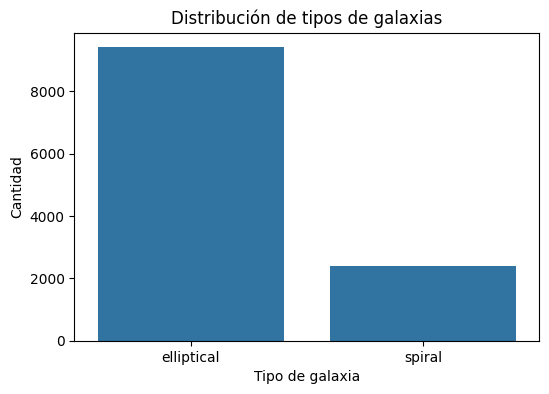

In [ ]:
print(df["target"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Distribución de tipos de galaxias")
plt.xlabel("Tipo de galaxia")
plt.ylabel("Cantidad")
plt.show()

Se observa un desbalance moderado entre las clases. Las galaxias elípticas representan aproximadamente el 80% de las observaciones, mientras que las galaxias espirales corresponden al 20% restante.

Este desbalance debe considerarse durante la evaluación de los modelos, ya que la exactitud por sí sola podría resultar engañosa.

### 2.b Exploración de relaciones entre variables

In [ ]:
# Variables numéricas

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
petromag_u,11787.0,18.821790,0.899913,14.346013,18.297297,18.944880,19.472777,21.945023
petromag_g,11787.0,17.165932,0.791078,12.771928,16.788728,17.361563,17.735371,18.949085
petromag_r,11787.0,16.331495,0.721533,12.178217,16.012561,16.549639,16.866133,17.706539
petromag_i,11787.0,15.935322,0.714976,11.837103,15.622070,16.148109,16.460490,17.266369
petromag_z,11787.0,15.671572,0.704404,11.687765,15.360709,15.863113,16.172187,16.954662
petror50_r,11787.0,3.019179,1.513397,0.962538,2.049916,2.579823,3.479284,19.713860
petror90_r,11787.0,8.173440,3.554434,3.001457,5.807772,7.318419,9.586545,36.452015
concentration,11787.0,2.788012,0.414232,1.686244,2.467863,2.872812,3.121837,5.582179
devab_r,11787.0,0.698450,0.179868,0.123314,0.579447,0.725421,0.839959,0.999991
u_g,11787.0,1.655858,0.347793,0.002761,1.408119,1.690868,1.869085,3.986334


El análisis descriptivo muestra que las variables presentan escalas diferentes. Por ejemplo, algunas características fotométricas poseen rangos considerablemente mayores que otras variables derivadas de color o concentración.

Esta diferencia de escalas justifica la necesidad de aplicar un proceso de estandarización antes de utilizar PCA y algunos algoritmos de clasificación sensibles a la magnitud de las variables.

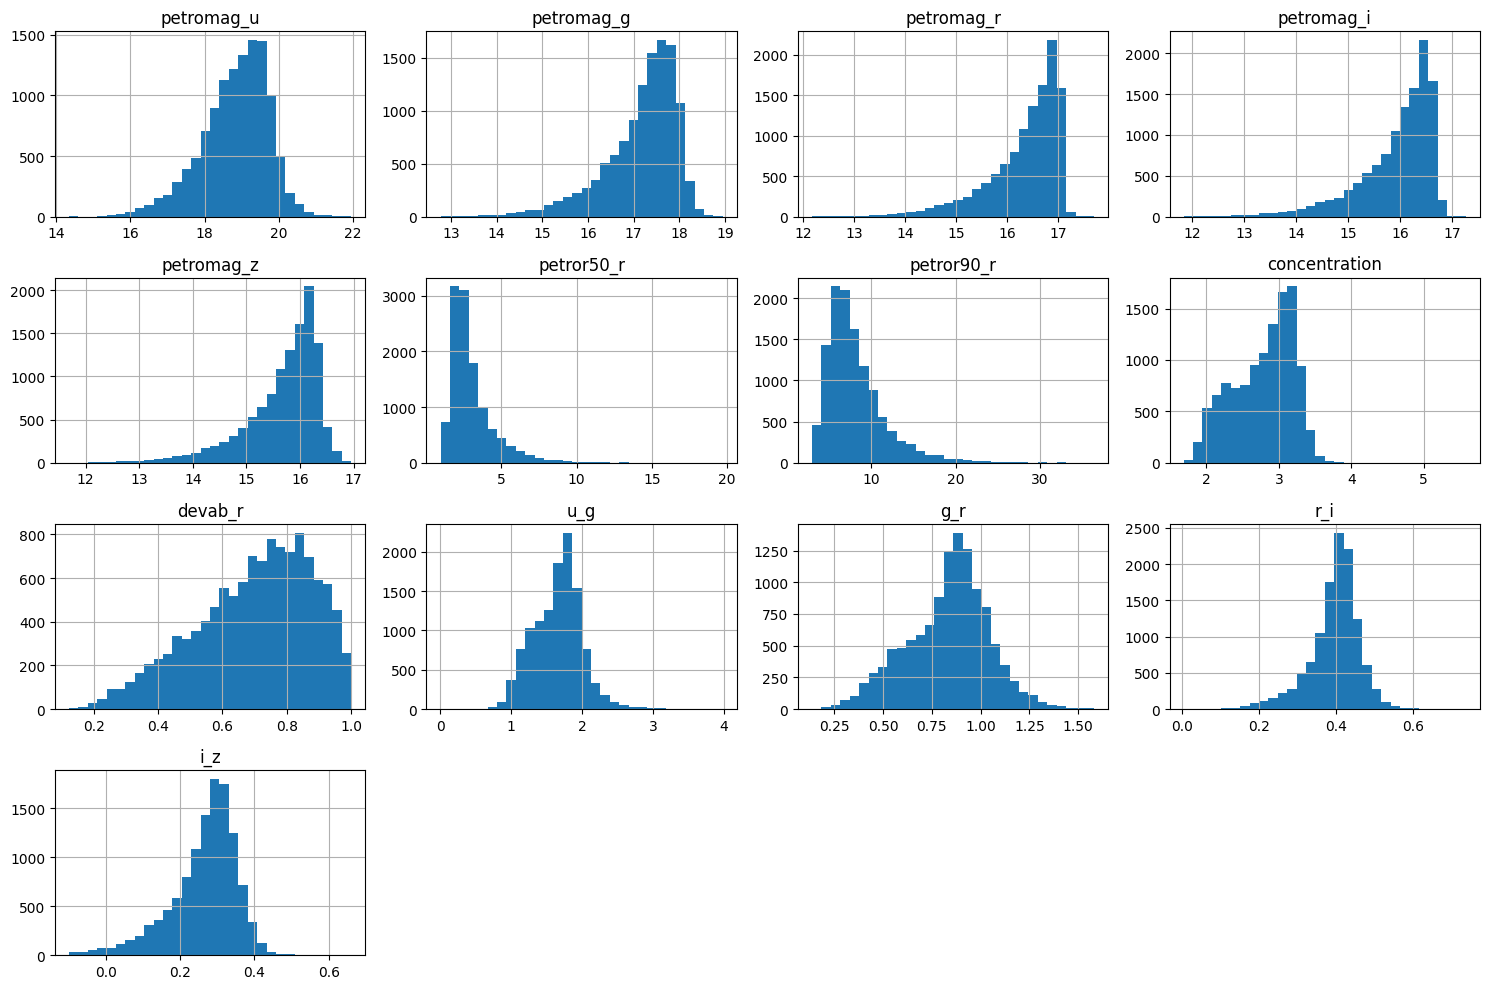

### 2.c Detectar posibles correlaciones o redundancias.

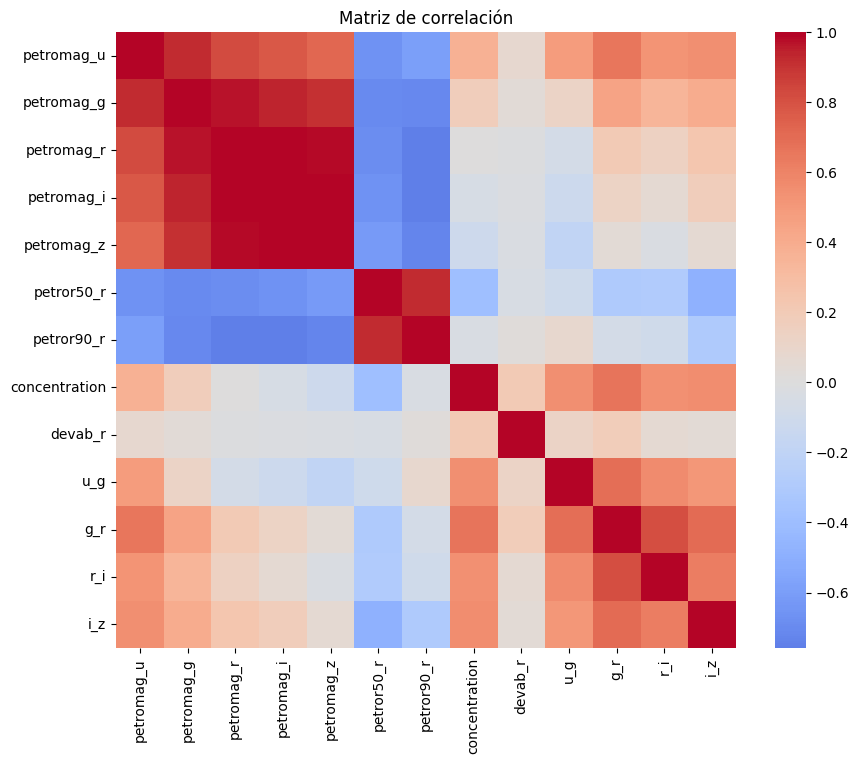

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

In [ ]:
corr_matrix = corr.abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Variables altamente correlacionadas:")
print(high_corr)

Variables altamente correlacionadas:
['petromag_g', 'petromag_r', 'petromag_i', 'petromag_z', 'petror90_r']


La matriz de correlación evidenció la presencia de algunas variables altamente correlacionadas, especialmente entre las magnitudes fotométricas (petromag_g, petromag_r, petromag_i y petromag_z).

Aunque estas correlaciones podrían indicar redundancia de información, se decidió mantener inicialmente todas las variables para evaluar posteriormente el efecto de PCA como técnica de reducción de dimensionalidad.



## 3. Preprocesamiento
### 3.a Escalado de variables

Los modelos basados en distancias y PCA son sensibles a la escala de las variables. Por esta razón se aplicará una estandarización utilizando StandardScaler.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Shape X_train:", X_train.shape)
print("Shape X_train_scaled:", X_train_scaled.shape)

print("\nPrimeras 5 filas escaladas:")
print(X_train_scaled[:5])

Shape X_train: (9429, 13)
Shape X_train_scaled: (9429, 13)

Primeras 5 filas escaladas:
[[-0.60002055 -0.46652056 -0.3135056  -0.30965254 -0.30905617  0.28727053
   0.12059    -0.7209488  -1.22307457 -0.49351788 -0.68470031 -0.07554214
  -0.04255756]
 [ 0.0590317  -0.27258227 -0.31008972 -0.29241139 -0.31322957 -0.07552733
   0.36590889  1.12852671  0.25683398  0.77062044  0.03680534 -0.22598565
   0.12485601]
 [-0.18685914 -0.30522396 -0.34597302 -0.36367134 -0.38175884 -0.91985734
  -0.94083878  0.45207078 -1.08936357  0.20892765  0.03691025  0.15607373
   0.09504339]
 [ 0.38154541  0.67134444  0.78428924  0.74367845  0.75449674 -0.24303619
  -0.69739236 -1.53274716 -1.38217606 -0.53568623 -0.16144707  0.52682697
   0.00764567]
 [ 0.45476742  0.31139924  0.29093232  0.26129847  0.17132937 -0.97606225
  -1.07132732  0.12728166 -0.31217046  0.46969204  0.17590341  0.35435096
   0.72650504]]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11787 entries, 0 to 11786
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   petromag_u     11787 non-null  float64
 1   petromag_g     11787 non-null  float64
 2   petromag_r     11787 non-null  float64
 3   petromag_i     11787 non-null  float64
 4   petromag_z     11787 non-null  float64
 5   petror50_r     11787 non-null  float64
 6   petror90_r     11787 non-null  float64
 7   concentration  11787 non-null  float64
 8   devab_r        11787 non-null  float64
 9   u_g            11787 non-null  float64
 10  g_r            11787 non-null  float64
 11  r_i            11787 non-null  float64
 12  i_z            11787 non-null  float64
 13  target         11787 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.3+ MB


### 3.b Tratamiento de valores atípicos

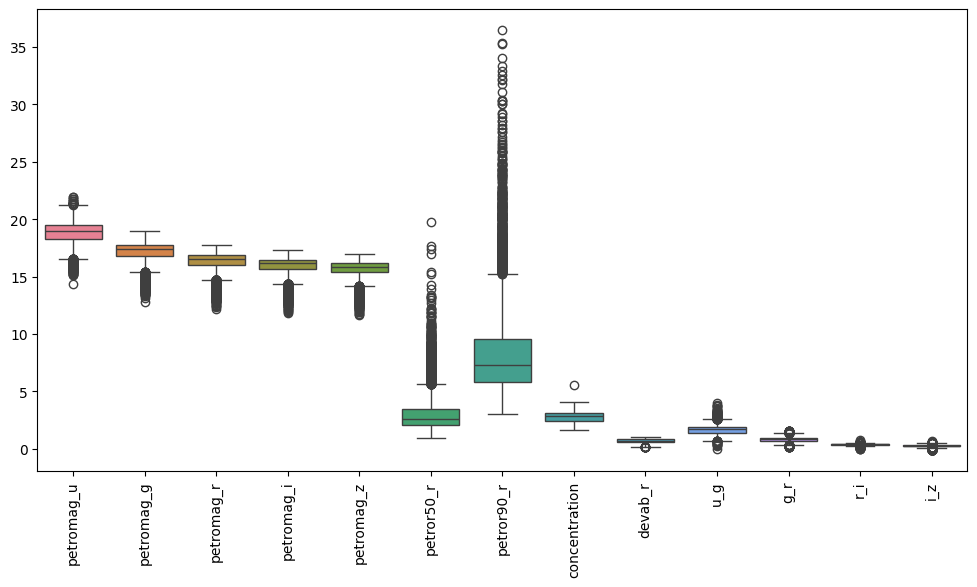

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=90)
plt.show()

Se verificó que el conjunto de datos no presenta valores nulos y que todas las variables predictoras son numéricas.

Mediante diagramas de caja se identificaron algunas observaciones extremas. Sin embargo, debido a que corresponden a mediciones astronómicas reales, estas podrían representar características válidas de determinadas galaxias y no errores de captura. Por esta razón se decidió conservar todos los registros para evitar la pérdida de información potencialmente relevante.



### 3.c Selección de variables

In [ ]:
corr_matrix = df.drop("target", axis=1).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Variables con correlación > 0.90:")
print(high_corr)

Variables con correlación > 0.90:
['petromag_g', 'petromag_r', 'petromag_i', 'petromag_z', 'petror90_r']


Tras analizar la matriz de correlación se identificaron algunas variables con correlaciones superiores a 0.90, especialmente entre las variables fotométricas petromag_g, petromag_r, petromag_i y petromag_z.

Aunque estas correlaciones sugieren la existencia de redundancia en parte de la información, no se eliminaron variables en esta etapa del análisis. Se decidió conservar las 13 variables predictoras para mantener la mayor cantidad posible de información y posteriormente evaluar técnicas de reducción de dimensionalidad mediante PCA.

Este enfoque permitirá determinar si es posible reducir el número de características sin afectar significativamente el rendimiento de los modelos de clasificación.

## 4 Reducción de dimensionalidad

### 4.a Aplicar PCA (Análisis de Componentes Principales).

Debido a la existencia de variables altamente correlacionadas, se aplicó Análisis de Componentes Principales (PCA) con el objetivo de reducir la dimensionalidad del conjunto de datos manteniendo la mayor cantidad posible de información.

Previamente, las variables fueron estandarizadas mediante StandardScaler para evitar que las diferencias de escala influyeran en los componentes principales.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

### 4.b Analizar la varianza explicada por los componentes.

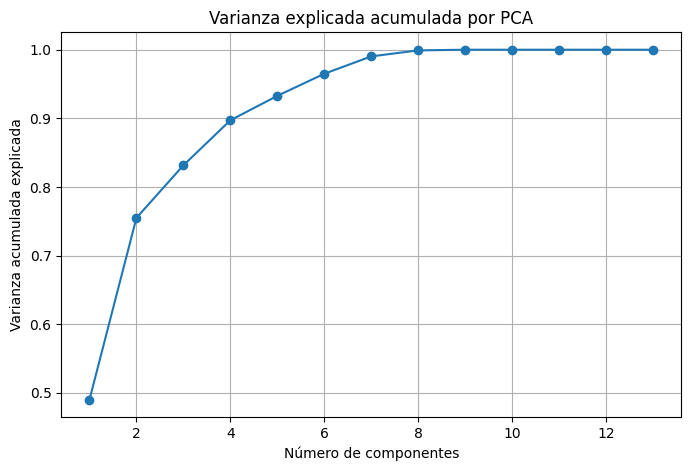

In [ ]:
varianza = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(varianza)+1),
    np.cumsum(varianza),
    marker='o'
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada explicada")
plt.title("Varianza explicada acumulada por PCA")
plt.grid(True)

plt.show()

In [ ]:
varianza_acumulada = np.cumsum(varianza)

n_componentes = np.argmax(varianza_acumulada >= 0.95) + 1

print(f"Componentes necesarios para explicar el 95% de la varianza: {n_componentes}")

Componentes necesarios para explicar el 95% de la varianza: 6


In [ ]:
pca_info = pd.DataFrame({
    "Componente": range(1, len(varianza)+1),
    "Varianza explicada": varianza,
    "Varianza acumulada": np.cumsum(varianza)
})

pca_info

,Componente,Varianza explicada,Varianza acumulada
0,1,4.898774e-01,0.489877
1,2,2.650420e-01,0.754919
2,3,7.660617e-02,0.831526
3,4,6.562765e-02,0.897153
4,5,3.563729e-02,0.932791
5,6,3.219403e-02,0.964985
6,7,2.531015e-02,0.990295
7,8,8.747412e-03,0.999042
8,9,9.578875e-04,1.000000
9,10,2.670005e-17,1.000000


In [ ]:
print(n_componentes)

6


### Interpretación de la varianza explicada

Los resultados muestran que el primer componente principal concentra cerca del 49% de la variabilidad presente en los datos. Al incorporar el segundo componente, la varianza acumulada supera el 75%.

A medida que se agregan más componentes, se conserva una mayor proporción de la información original. En este caso, se observó que con únicamente 6 componentes principales es posible conservar aproximadamente el 96.5% de la varianza total.

Esto sugiere que gran parte de la información contenida en las 13 variables originales puede representarse mediante un número menor de componentes, reduciendo la redundancia generada por las variables altamente correlacionadas.

### 4.c Comparar resultados con y sin PCA.

In [ ]:
pca_info

,Componente,Varianza explicada,Varianza acumulada
0,1,4.898774e-01,0.489877
1,2,2.650420e-01,0.754919
2,3,7.660617e-02,0.831526
3,4,6.562765e-02,0.897153
4,5,3.563729e-02,0.932791
5,6,3.219403e-02,0.964985
6,7,2.531015e-02,0.990295
7,8,8.747412e-03,0.999042
8,9,9.578875e-04,1.000000
9,10,2.670005e-17,1.000000


In [ ]:
pca_final = PCA(n_components=n_componentes)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("Variables originales:", X_train_scaled.shape[1])
print("Componentes PCA:", X_train_pca.shape[1])

Variables originales: 13
Componentes PCA: 6


### Resultado de la reducción de dimensionalidad

El conjunto de datos original contenía 13 variables predictoras. Tras aplicar PCA se obtuvo una representación equivalente utilizando únicamente 6 componentes principales, conservando más del 95% de la información presente en los datos originales.

Esta reducción representa una disminución aproximada del 54% en el número de variables utilizadas por los modelos posteriores.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# SVM sin PCA
svm_original = SVC()
svm_original.fit(X_train_scaled, y_train)

pred_original = svm_original.predict(X_test_scaled)
acc_original = accuracy_score(y_test, pred_original)

# SVM con PCA
svm_pca = SVC()
svm_pca.fit(X_train_pca, y_train)

pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, pred_pca)

print(f"Accuracy SVM sin PCA: {acc_original:.4f}")
print(f"Accuracy SVM con PCA: {acc_pca:.4f}")

Accuracy SVM sin PCA: 0.9440
Accuracy SVM con PCA: 0.9406


In [ ]:
comparacion_pca = pd.DataFrame({
    "Modelo": ["SVM sin PCA", "SVM con PCA"],
    "Accuracy": [acc_original, acc_pca]
})

comparacion_pca

,Modelo,Accuracy
0,SVM sin PCA,0.944020
1,SVM con PCA,0.940628


### Comparación de resultados con y sin PCA

Para evaluar el efecto de PCA, se comparó el rendimiento de un modelo SVM utilizando las variables originales y utilizando únicamente los componentes principales obtenidos.

El modelo entrenado con las variables originales alcanzó una precisión de 94.40%, mientras que el modelo basado en PCA obtuvo una precisión de 94.06%.

La diferencia entre ambos resultados fue muy pequeña, lo que indica que la reducción de dimensionalidad tuvo un impacto mínimo sobre el desempeño del modelo. Esto permite concluir que los 6 componentes principales conservan la mayor parte de la información necesaria para realizar la clasificación.

## 5. Modelado

### 5.a Analizar qué modelos de los estudiados en clase son adecuados para resolver el problema planteado y justificar la elección.

Se seleccionaron cuatro algoritmos de clasificación estudiados durante el curso:

- Regresión Logística: modelo lineal ampliamente utilizado en problemas de clasificación binaria.
- Árbol de Decisión: modelo interpretable capaz de capturar relaciones no lineales.
- Random Forest: método de ensamble basado en múltiples árboles de decisión que suele ofrecer un alto rendimiento predictivo.
- Support Vector Machine (SVM): algoritmo eficaz para problemas de clasificación en espacios de alta dimensionalidad.

La comparación entre estos modelos permitirá identificar cuál ofrece el mejor equilibrio entre precisión, capacidad de generalización e interpretabilidad.

### 5.b Entrenar y evaluar distintos modelos de clasificación.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [ ]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

resultados = []

for nombre, modelo in modelos.items():

    modelo.fit(X_train_scaled, y_train)

    pred = modelo.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)

    resultados.append([nombre, accuracy])

resultados_df = pd.DataFrame(
    resultados,
    columns=["Modelo", "Accuracy"]
)

resultados_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Modelo,Accuracy
3,SVM,0.944020
2,Random Forest,0.940204
0,Logistic Regression,0.914758
1,Decision Tree,0.906701


### 5.c Comparar los resultados obtenidos y seleccionar un modelo final, justificando la decisión.

Todos los modelos evaluados lograron una precisión superior al 90%. Esto sugiere que las características incluidas en el conjunto de datos permiten diferenciar adecuadamente entre galaxias espirales y elípticas.

El mejor rendimiento fue obtenido por SVM, alcanzando una exactitud de 94.40%, seguido muy de cerca por Random Forest con 94.02%.

Por su parte, la Regresión Logística obtuvo un rendimiento competitivo (91.48%), mientras que el Árbol de Decisión presentó el resultado más bajo (90.67%), posiblemente debido a una mayor sensibilidad al sobreajuste al utilizar un único árbol.

Dado que SVM alcanzó la mayor precisión, se considera inicialmente como el candidato más sólido para el modelo final.

## 6 Evaluación

### 6.a Definir y aplicar métricas adecuadas para evaluar los modelos



In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

svm_model = SVC()

svm_model.fit(
    X_train_scaled,
    y_train
)

y_pred = svm_model.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["elliptical","spiral"]
    )
)

              precision    recall  f1-score   support

  elliptical       0.95      0.98      0.97      1881
      spiral       0.91      0.81      0.85       477

    accuracy                           0.94      2358
   macro avg       0.93      0.89      0.91      2358
weighted avg       0.94      0.94      0.94      2358



### Interpretación de las métricas

La evaluación del modelo SVM muestra una exactitud global del 94%, lo que indica una elevada capacidad para clasificar correctamente las galaxias del conjunto de datos.

Para la clase "elliptical", el modelo obtuvo una precisión del 95% y un recall del 98%, demostrando un excelente desempeño en la identificación de este tipo de galaxias.

Para la clase "spiral", la precisión alcanzó el 91%, mientras que el recall fue del 81%. Esto indica que el modelo identifica correctamente la mayoría de las galaxias espirales, aunque algunas son clasificadas erróneamente como elípticas.

El F1-score ponderado de 0.94 confirma un buen equilibrio entre precisión y capacidad de recuperación de ambas clases.

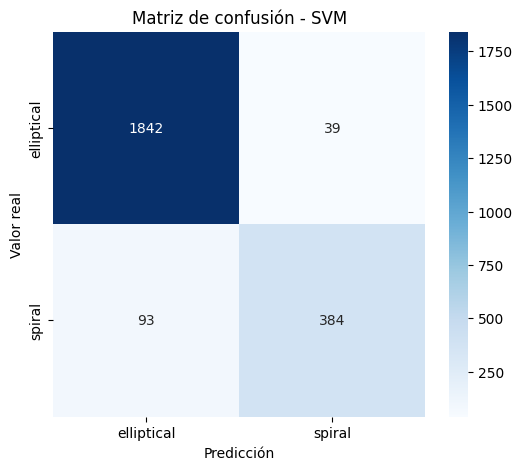

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["elliptical","spiral"],
    yticklabels=["elliptical","spiral"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - SVM")

plt.show()

### Interpretación de la matriz de confusión

La matriz de confusión permite observar con mayor detalle el comportamiento del modelo.

Se clasificaron correctamente 1842 galaxias elípticas y 384 galaxias espirales. Los errores más frecuentes corresponden a galaxias espirales clasificadas como elípticas (93 casos), mientras que únicamente 39 galaxias elípticas fueron clasificadas erróneamente como espirales.

Este comportamiento es coherente con el desbalance existente en el conjunto de datos, donde las galaxias elípticas representan la mayoría de las observaciones.

## 7. Conclusión

### 7.a Comparar los resultados obtenidos para cada modelo entrenado

Se evaluaron cuatro modelos de clasificación: Regresión Logística, Árbol de Decisión, Random Forest y SVM. Todos obtuvieron resultados superiores al 90% de exactitud, lo que demuestra que las variables disponibles contienen información útil para diferenciar galaxias espirales y elípticas.

El mejor resultado fue obtenido por SVM con una exactitud de 94.40%, seguido muy de cerca por Random Forest con 94.02%. La Regresión Logística alcanzó una exactitud de 91.48%, mientras que el Árbol de Decisión obtuvo 90.67%.

En general, todos los modelos mostraron un desempeño satisfactorio, aunque SVM y Random Forest fueron los que lograron una mejor capacidad de clasificación.

### 7.b Justificar la elección del modelo final

El modelo seleccionado fue SVM debido a que presentó la mayor exactitud entre todos los algoritmos evaluados.

Además, las métricas de precisión, recall y F1-score mostraron un comportamiento equilibrado para ambas clases. La matriz de confusión también evidenció una buena capacidad para identificar correctamente tanto galaxias elípticas como espirales.

Por estos motivos, SVM se considera el modelo más adecuado para este conjunto de datos.

### 7.c Discutir el papel de PCA y la interpretabilidad de los modelos

La aplicación de PCA permitió reducir el número de variables de 13 a 6 componentes principales, conservando aproximadamente el 96.5% de la varianza total.

Al comparar el rendimiento de SVM con y sin PCA, se observó una diferencia muy pequeña entre ambos resultados (94.40% frente a 94.06%). Esto indica que la reducción de dimensionalidad conservó prácticamente toda la información relevante para la clasificación.

Sin embargo, aunque PCA ayuda a simplificar los datos y reducir la redundancia entre variables, también disminuye la interpretabilidad del modelo, ya que los componentes principales son combinaciones matemáticas de las variables originales y no representan características físicas específicas de las galaxias.

En conclusión, los resultados obtenidos muestran que las propiedades observacionales incluidas en el conjunto de datos permiten clasificar galaxias con un alto nivel de precisión, siendo SVM el modelo que ofreció el mejor desempeño.